In [1]:
# regression-multiple-methods.ipynb

import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
# To ensure reproducibility
np.random.seed(42)

# Read data from Excel file
file_path = 'data/Assignment_8_regression_multiple_methods.xlsx'
train_data = pd.read_excel(file_path, sheet_name='train')
test_data = pd.read_excel(file_path, sheet_name='test')

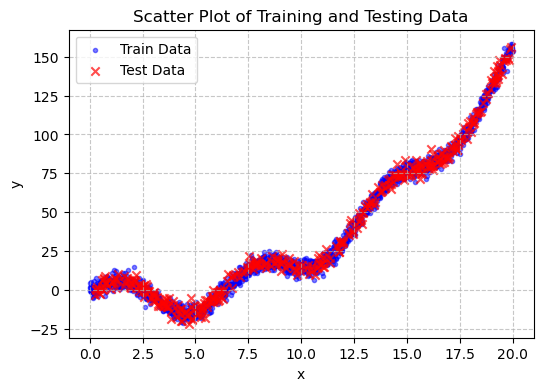

In [4]:
# Scatter Plot with 'x1' and 'y' columns ---

# Select the specified columns
x_train = train_data['x']
y_train = train_data['y']
x_test = test_data['x']
y_test = test_data['y']

# Create the scatter plot
plt.figure(figsize=(6, 4))

# Scatter plot for training data (blue circles)
plt.scatter(x_train, y_train, color='blue', label='Train Data', alpha=0.5, marker='.')

# Scatter plot for test data (red crosses)
plt.scatter(x_test, y_test, color='red', label='Test Data', alpha=0.7, marker='x')

# Add titles, labels, and legend
plt.title('Scatter Plot of Training and Testing Data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

In [3]:
# Separate features and target variable in train data
X_train = train_data.drop(columns=['y'])
y_train = train_data['y']

# Separate features and target variable in test data
X_test = test_data.drop(columns=['y'])
y_test = test_data['y']

In [6]:
# # Adding outliers (UNCOMMENT ONLY WHEN REQUIRED! SEE THE PROBLEM STATEMENTs ...)
# X_train = np.array(list(X_train['x1']) + [X_train['x1'].mean() + x for x in np.random.randn(5)]).reshape(-1,1)
# y_train = np.array(list(y_train) + [y_train.max() + 4 + x for x in np.random.randn(5)])

In [4]:
# Use PolynomialFeatures to create new features features
poly = PolynomialFeatures(degree=1)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [5]:
# standardization of the data
scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

In [6]:
####################################
# Save the augmented data set to a file for review

# Create dataframe with test data and additional features
# Get feature names
feature_names = poly.get_feature_names_out()
augmented_data = pd.DataFrame(X_train_poly, columns=feature_names)
augmented_data['y'] = train_data['y']

# # Write dataframe to CSV
augmented_data.to_csv('augmented_train_data.csv', index=False)
####################################
####################################
# Save the augmented data set to a file for review

# Create dataframe with test data and additional features
# Get feature names
feature_names = poly.get_feature_names_out()
augmented_data = pd.DataFrame(X_test_poly, columns=feature_names)
augmented_data['y'] = test_data['y']

# # Write dataframe to CSV
augmented_data.to_csv('augmented_test_data.csv', index=False)
####################################

In [7]:
# Algorithms
algorithms = {
    'Linear Regression': LinearRegression(),
    'SVM Regression': SVR(kernel='poly'),  # Adjust kernel as needed
    'RandomForest': RandomForestRegressor(),
    'XGBoost': GradientBoostingRegressor(),
    'knn': KNeighborsRegressor(),
    'Neural Network-10': MLPRegressor(hidden_layer_sizes=[10], max_iter=20000),
}

# Metric tables
metric_table_train = pd.DataFrame()
metric_table_test = pd.DataFrame()

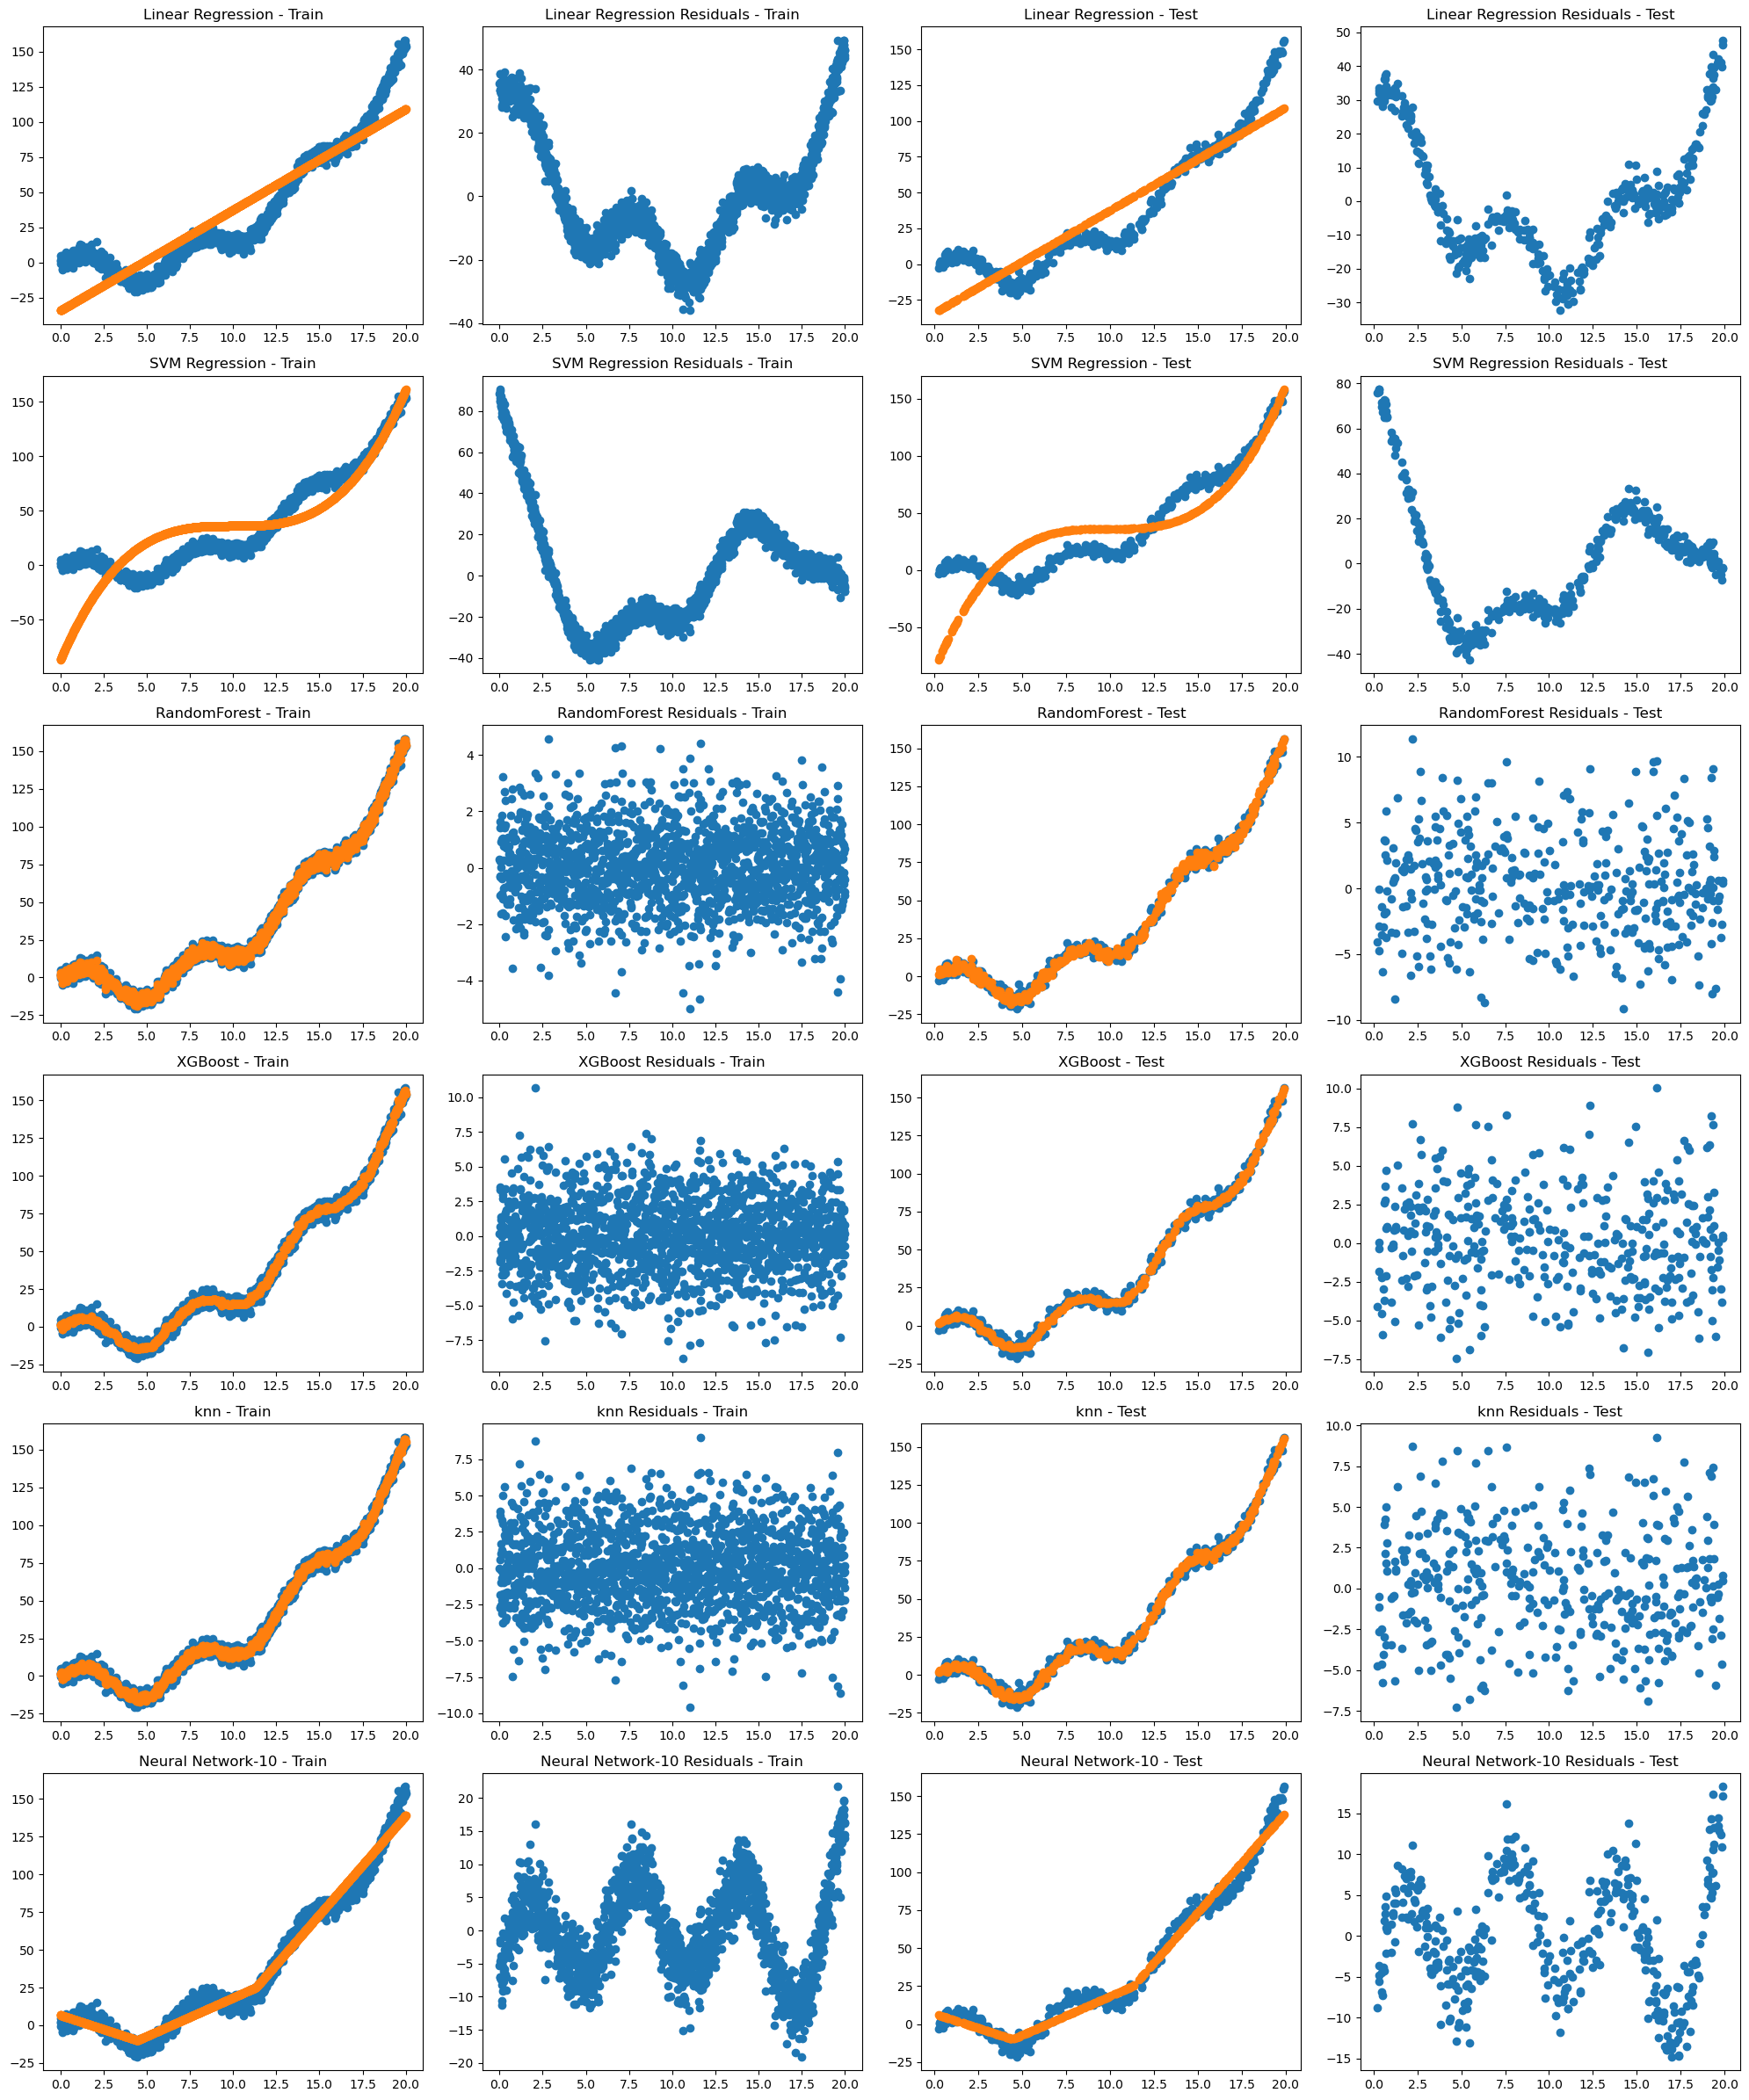

In [8]:
# Create a grid of subplots
fig, axs = plt.subplots(len(algorithms), 4, figsize=(20, 4 * len(algorithms)))
fig_row = -1

# Run the algorithms ... create metrics and plots
for algorithm_name, algorithm in algorithms.items():

    # Train model
    algorithm.fit(X_train_poly, y_train)

    # Train predictions
    y_train_pred = algorithm.predict(X_train_poly)

    # Test predictions
    y_test_pred = algorithm.predict(X_test_poly)

    # Train metrics
    r2_train = algorithm.score(X_train_poly, y_train)
    rmse_train = root_mean_squared_error(y_train, y_train_pred)

    # Test metrics
    r2_test = algorithm.score(X_test_poly, y_test)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)

    # Additional metrics using statsmodels for all algorithms
    residuals_train = y_train - y_train_pred
    residuals_test = y_test - y_test_pred

    durbin_watson_stat_train = sm.stats.durbin_watson(residuals_train)
    jb_stat_train, jb_p_value_train, _, _ = sm.stats.jarque_bera(residuals_train)

    durbin_watson_stat_test = sm.stats.durbin_watson(residuals_test)
    jb_stat_test, jb_p_value_test, _, _ = sm.stats.jarque_bera(residuals_test)

    # Update metric tables
    metric_table_train.at[algorithm_name, 'R-squared'] = r2_train
    metric_table_train.at[algorithm_name, 'RMSE'] = rmse_train
    metric_table_train.at[algorithm_name, 'Durbin-Watson'] = durbin_watson_stat_train
    metric_table_train.at[algorithm_name, 'Jarque-Bera'] = jb_stat_train
    metric_table_train.at[algorithm_name, 'JB P-value'] = jb_p_value_train

    metric_table_test.at[algorithm_name, 'R-squared'] = r2_test
    metric_table_test.at[algorithm_name, 'RMSE'] = rmse_test
    metric_table_test.at[algorithm_name, 'Durbin-Watson'] = durbin_watson_stat_test
    metric_table_test.at[algorithm_name, 'Jarque-Bera'] = jb_stat_test
    metric_table_test.at[algorithm_name, 'JB P-value'] = jb_p_value_test

    # Create the plots
    fig_row = fig_row+1

    axs[fig_row, 0].scatter(X_train, y_train)
    axs[fig_row, 0].scatter(X_train, y_train_pred)
    axs[fig_row, 0].set_title(algorithm_name + " - Train")

    axs[fig_row, 1].scatter(X_train, residuals_train)
    axs[fig_row, 1].set_title(algorithm_name + " Residuals - Train")

    axs[fig_row, 2].scatter(X_test, y_test)
    axs[fig_row, 2].scatter(X_test, y_test_pred)
    axs[fig_row, 2].set_title(algorithm_name + " - Test")

    axs[fig_row, 3].scatter(X_test, residuals_test)
    axs[fig_row, 3].set_title(algorithm_name + " Residuals - Test")
############################

plt.tight_layout()
plt.show()

In [9]:
# Display the metrics' Tables
print("Metrics - Train Data:\n")
print(metric_table_train.to_string())
print("-------------------------------------------------")

print("Metrics - Test Data:\n")
print(metric_table_test.to_string())

Metrics - Train Data:

                   R-squared       RMSE  Durbin-Watson  Jarque-Bera    JB P-value
Linear Regression   0.829553  18.656644       2.024608   117.827752  2.594351e-26
SVM Regression      0.638358  27.175561       1.987561   251.590113  2.332926e-55
RandomForest        0.999132   1.331492       2.053460     9.115382  1.048624e-02
XGBoost             0.996693   2.598827       2.089983     0.569595  7.521666e-01
knn                 0.996598   2.635583       2.092051     0.594478  7.428664e-01
Neural Network-10   0.977496   6.779078       2.042096    16.589599  2.498126e-04
-------------------------------------------------
Metrics - Test Data:

                   R-squared       RMSE  Durbin-Watson  Jarque-Bera    JB P-value
Linear Regression   0.850458  18.078457       1.904427    25.441873  2.987910e-06
SVM Regression      0.689803  26.037513       1.990964    35.111435  2.374919e-08
RandomForest        0.993391   3.800531       2.086859     3.053705  2.172183e-01
XGB

### Residual Analysis Plots

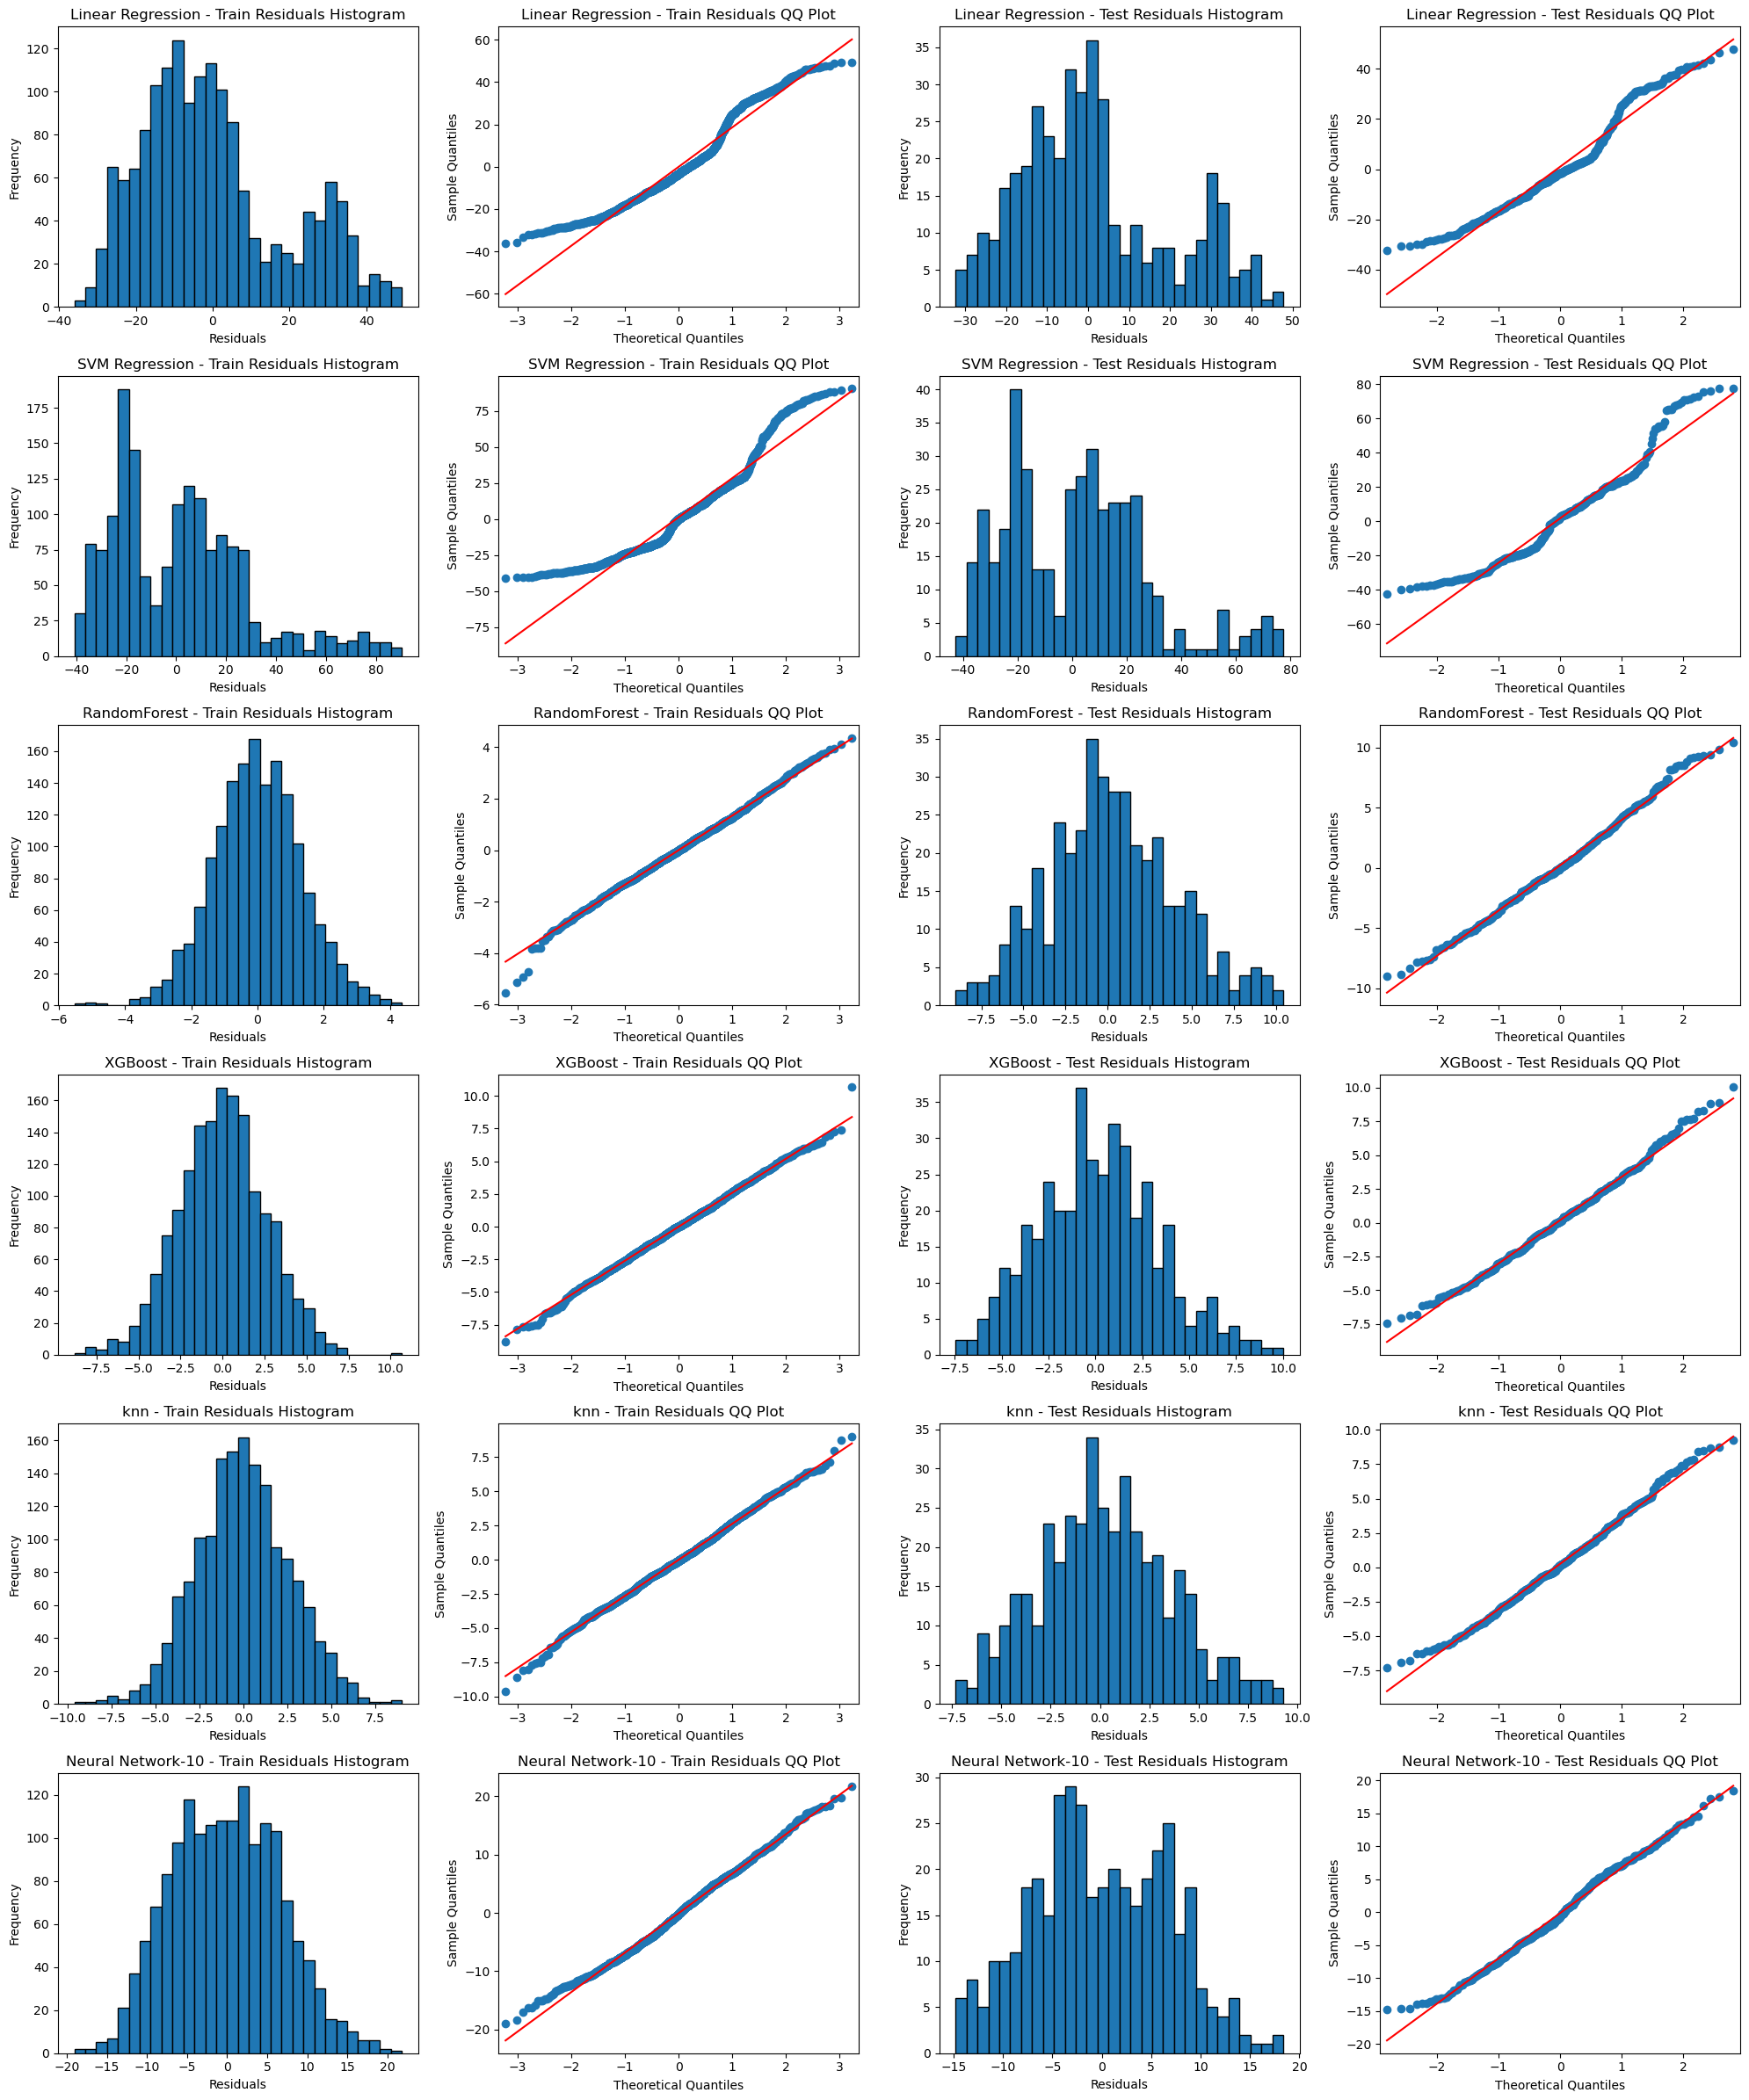

In [10]:
# Create a grid of subplots for residual analysis
fig_residuals, axs_residuals = plt.subplots(len(algorithms), 4, figsize=(20, 4 * len(algorithms)))
fig_row_residuals = -1

for algorithm_name, algorithm in algorithms.items():

    # Train model (re-train to ensure access to predictions if not already available in this scope)
    # These predictions are already available from the previous cell's execution,
    # but re-running fit and predict here ensures the current cell is self-contained
    # if run independently.
    algorithm.fit(X_train_poly, y_train)
    y_train_pred = algorithm.predict(X_train_poly)
    y_test_pred = algorithm.predict(X_test_poly)

    residuals_train = y_train - y_train_pred
    residuals_test = y_test - y_test_pred

    fig_row_residuals = fig_row_residuals + 1

    # Training Residuals: Histogram
    axs_residuals[fig_row_residuals, 0].hist(residuals_train, bins=30, edgecolor='black')
    axs_residuals[fig_row_residuals, 0].set_title(f'{algorithm_name} - Train Residuals Histogram')
    axs_residuals[fig_row_residuals, 0].set_xlabel('Residuals')
    axs_residuals[fig_row_residuals, 0].set_ylabel('Frequency')

    # Training Residuals: QQ Plot
    sm.qqplot(residuals_train, line='s', ax=axs_residuals[fig_row_residuals, 1])
    axs_residuals[fig_row_residuals, 1].set_title(f'{algorithm_name} - Train Residuals QQ Plot')

    # Test Residuals: Histogram
    axs_residuals[fig_row_residuals, 2].hist(residuals_test, bins=30, edgecolor='black')
    axs_residuals[fig_row_residuals, 2].set_title(f'{algorithm_name} - Test Residuals Histogram')
    axs_residuals[fig_row_residuals, 2].set_xlabel('Residuals')
    axs_residuals[fig_row_residuals, 2].set_ylabel('Frequency')

    # Test Residuals: QQ Plot
    sm.qqplot(residuals_test, line='s', ax=axs_residuals[fig_row_residuals, 3])
    axs_residuals[fig_row_residuals, 3].set_title(f'{algorithm_name} - Test Residuals QQ Plot')

plt.tight_layout()
plt.show();